In [12]:
###########XG_BOOST WITH NORMAL LINE OR THIN LINE ##########

# 📦 Ensure XGBoost is installed
!pip install xgboost --quiet

# 📚 Imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from xgboost import XGBRegressor
from sklearn.metrics import mean_squared_error
from google.colab import files

# 📁 Upload your Excel file
uploaded = files.upload()

Saving fmd new (1).xlsx to fmd new (1) (1).xlsx


/tmp/ipython-input-804101855.py:6: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df = df.sort_index().fillna(method='ffill')


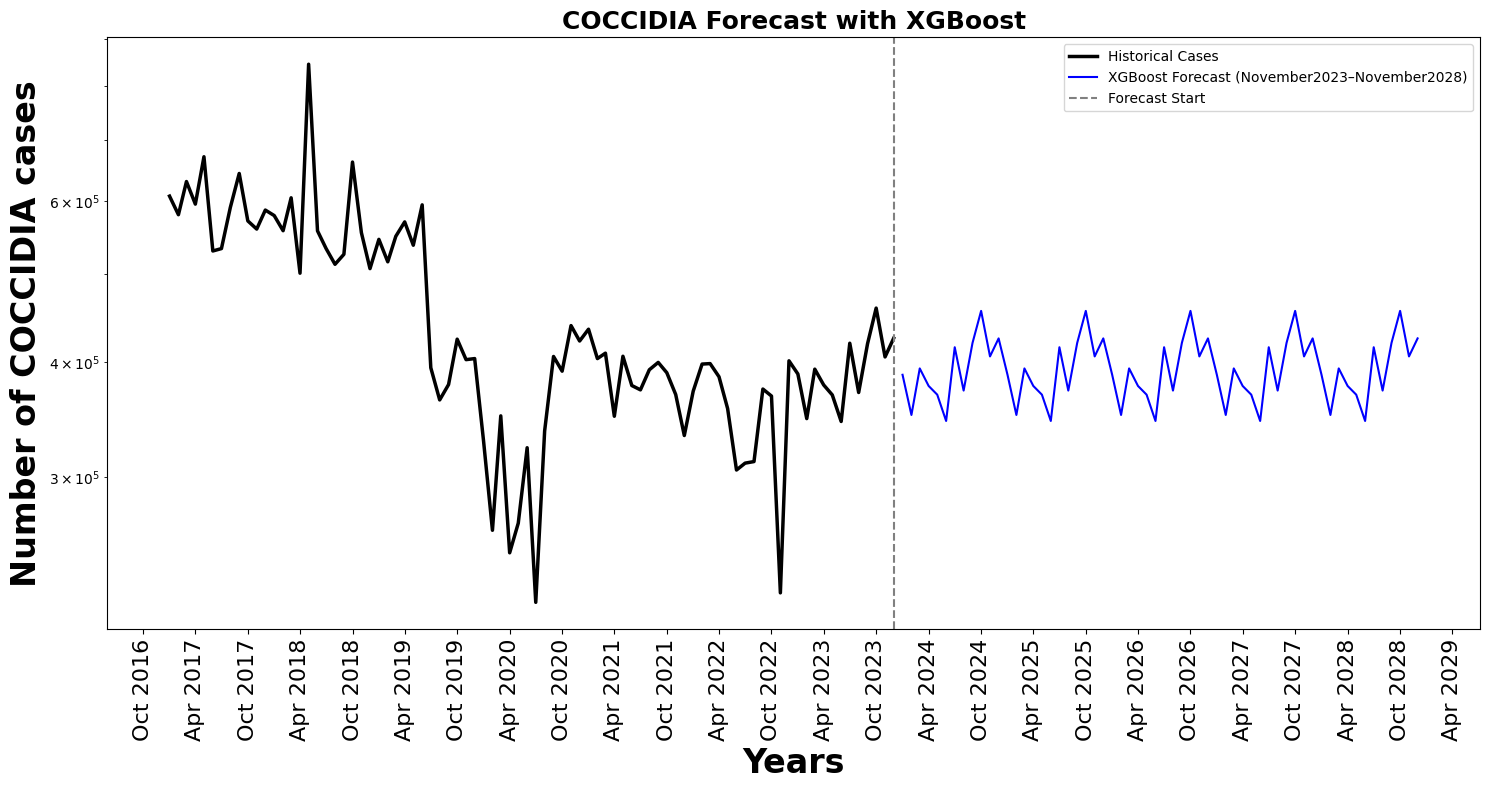

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [13]:


# 🔄 Read & preprocess
file_name = list(uploaded.keys())[0]
df = pd.read_excel(file_name, sheet_name='Sheet12')
df['Date'] = pd.to_datetime(df['Date'])
df = df.set_index('Date').asfreq('MS')
df = df.sort_index().fillna(method='ffill')

# 🧠 Add 1 and log-transform the cases
df['COCCIDIA_Cases'] = df['COCCIDIA_Cases'] + 1  # Avoid log(0)
df['Cases_log'] = np.log(df['COCCIDIA_Cases'])

# 🧠 Time-based features
def create_time_features(df):
    df = df.copy()
    df['year'] = df.index.year
    df['month'] = df.index.month
    df['sin_month'] = np.sin(2 * np.pi * df['month'] / 12)
    df['cos_month'] = np.cos(2 * np.pi * df['month'] / 12)
    return df

df_feat = create_time_features(df)
X = df_feat.drop(columns=['COCCIDIA_Cases', 'Cases_log'])
y = df_feat['Cases_log']

# 🤖 Train XGBoost on log-transformed data
model = XGBRegressor(objective='reg:squarederror', n_estimators=100, learning_rate=0.1, random_state=42)
model.fit(X, y)

# 📅 Forecast dates to Dec 2028
last_date = df.index[-1]
future_dates = pd.date_range(start=last_date + pd.DateOffset(months=1), end='2028-12-01', freq='MS')
future_df = pd.DataFrame(index=future_dates)
future_df = create_time_features(future_df)

# 🔮 Predict in log space
log_preds = model.predict(future_df)
forecast_cases = np.exp(log_preds) - 1  # Undo log and subtract 1 to match original scale
forecast_series = pd.Series(forecast_cases, index=future_dates)

# 📈 Plotting in log scale (10^y)

# ✅ 7. Plot with Roboto font
plt.figure(figsize=(15, 8))
plt.plot(df.index, df['COCCIDIA_Cases'], label='Historical Cases', color='black', linewidth=2.5)
plt.plot(forecast_series.index, forecast_series, label='XGBoost Forecast (November2023–November2028)', color='blue')
plt.axvline(df.index[-1], color='gray', linestyle='--', label='Forecast Start')

plt.yscale('log')

# Title, axis labels with larger, bold fonts
plt.title('COCCIDIA Forecast with XGBoost', fontsize=18, fontweight='bold')
plt.xlabel('Years', fontsize=24, fontweight='bold')
plt.ylabel('Number of COCCIDIA cases', fontsize=24, fontweight='bold')

# Axis tick label sizes
plt.tick_params(axis='both', labelsize=16)

# Legend
plt.legend()

# Date formatting
import matplotlib.dates as mdates
plt.gca().xaxis.set_major_locator(mdates.MonthLocator(interval=6))
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
plt.xticks(rotation=90)

# Layout and save
plt.tight_layout()
plt.savefig("COCCIDIA_xgboost.tiff", dpi=300, format='tiff')
plt.show()

# ✅ 8. Download TIFF
files.download("COCCIDIA_xgboost.tiff")




In [14]:
#############RMSE OF XG-BOOST###########

from sklearn.metrics import mean_squared_error
from math import sqrt

# Predict on training data
y_pred_log = model.predict(X)

# Back-transform predictions and actuals from log scale
y_pred_cases = np.exp(y_pred_log) - 1
y_true_cases = df['COCCIDIA_Cases'].values

# Calculate RMSE
rmse = sqrt(mean_squared_error(y_true_cases, y_pred_cases))
print(f'XGBoost Train RMSE: {rmse:.2f}')


XGBoost Train RMSE: 2931.40


In [16]:
#############RMSE, MAE, R², and Accuracy of XGBoost###########

from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from math import sqrt
import numpy as np

# Predict on training data
y_pred_log = model.predict(X)

# Back-transform predictions and actuals from log scale
y_pred_cases = np.exp(y_pred_log) - 1
y_true_cases = df['COCCIDIA_Cases'].values

# Calculate RMSE
rmse = sqrt(mean_squared_error(y_true_cases, y_pred_cases))

# Calculate MAE
mae = mean_absolute_error(y_true_cases, y_pred_cases)

# Calculate R²
r2 = r2_score(y_true_cases, y_pred_cases)

# Calculate MAPE (Mean Absolute Percentage Error) as accuracy-like metric
mape = np.mean(np.abs((y_true_cases - y_pred_cases) / y_true_cases)) * 100
accuracy = 100 - mape

# Print results
print(f'XGBoost Train RMSE: {rmse:.2f}')
print(f'XGBoost Train MAE: {mae:.2f}')
print(f'XGBoost Train R²: {r2:.4f}')
print(f'XGBoost Train Accuracy (100 - MAPE): {accuracy:.2f}%')


XGBoost Train RMSE: 2931.40
XGBoost Train MAE: 2092.59
XGBoost Train R²: 0.9994
XGBoost Train Accuracy (100 - MAPE): 99.50%


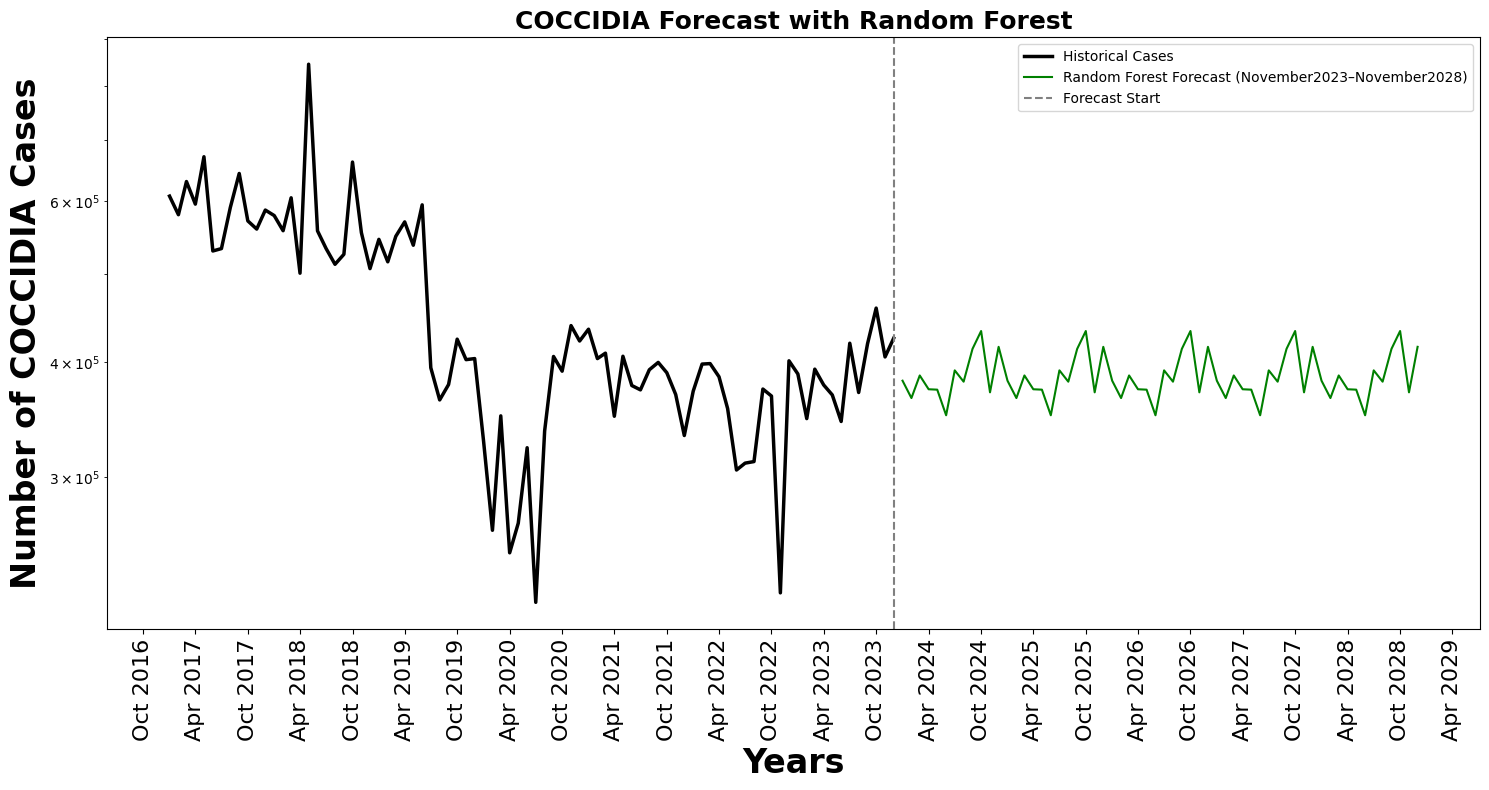

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [17]:
################# RANDOM FOREST###########################
from sklearn.ensemble import RandomForestRegressor

# 🎯 Train Random Forest on log-transformed data
rf_model = RandomForestRegressor(n_estimators=100, random_state=42)
rf_model.fit(X, y)

# 🔮 Predict with Random Forest in log space
log_preds_rf = rf_model.predict(future_df)
forecast_cases_rf = np.exp(log_preds_rf) - 1  # Undo log and subtract 1
forecast_series_rf = pd.Series(forecast_cases_rf, index=future_dates)

# 📈 Plotting Random Forest forecast
plt.figure(figsize=(15, 8))
plt.plot(df.index, df['COCCIDIA_Cases'], label='Historical Cases', color='black', linewidth=2.5)
plt.plot(forecast_series_rf.index, forecast_series_rf, label='Random Forest Forecast (November2023–November2028)', color='green')
plt.axvline(df.index[-1], color='gray', linestyle='--', label='Forecast Start')

plt.yscale('log')

# Title and axis labels
plt.title('COCCIDIA Forecast with Random Forest', fontsize=18, fontweight='bold')
plt.xlabel('Years', fontsize=24, fontweight='bold')
plt.ylabel('Number of COCCIDIA Cases', fontsize=24, fontweight='bold')
plt.tick_params(axis='both', labelsize=16)
plt.legend()

# Date formatting
import matplotlib.dates as mdates
plt.gca().xaxis.set_major_locator(mdates.MonthLocator(interval=6))
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
plt.xticks(rotation=90)

# Layout and save
plt.tight_layout()
plt.savefig("COCCIDIA_randomforest.tiff", dpi=300, format='tiff')
plt.show()

# ✅ Download TIFF
from google.colab import files
files.download("COCCIDIA_randomforest.tiff")



In [18]:
############RMSE, MAE, R², and Accuracy of Random Forest###########

from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import numpy as np

# 🔍 Predict on the training set (log scale)
log_preds_train = rf_model.predict(X)

# ✅ RMSE in log scale
rmse_log = np.sqrt(mean_squared_error(y, log_preds_train))
print(f"RMSE (log-transformed): {rmse_log:.4f}")

# 🔁 Back-transform to original scale
y_actual = np.exp(y) - 1
y_predicted = np.exp(log_preds_train) - 1

# ✅ RMSE in original scale
rmse_original = np.sqrt(mean_squared_error(y_actual, y_predicted))
print(f"RMSE (original scale): {rmse_original:.2f}")

# ✅ MAE in original scale
mae = mean_absolute_error(y_actual, y_predicted)
print(f"MAE (original scale): {mae:.2f}")

# ✅ R² in original scale
r2 = r2_score(y_actual, y_predicted)
print(f"R² (original scale): {r2:.4f}")

# ✅ MAPE and Accuracy
mape = np.mean(np.abs((y_actual - y_predicted) / y_actual)) * 100
accuracy = 100 - mape
print(f"Accuracy (100 - MAPE): {accuracy:.2f}%")



RMSE (log-transformed): 0.0544
RMSE (original scale): 25538.63
MAE (original scale): 17181.32
R² (original scale): 0.9510
Accuracy (100 - MAPE): 96.03%


In [ ]:
###########XG_BOOST WITH NORMAL LINE OR THICK LINE ##########

# ✅ 7. Plot with Roboto font
plt.figure(figsize=(18, 10))

plt.plot(df.index, df['Cases'], label='Historical Cases', color='black', linewidth=4)
plt.plot(forecast_series.index, forecast_series, label='XGBoost Forecast (2025–2028)', color='blue', linewidth=2)
plt.axvline(df.index[-1], color='gray', linestyle='--', linewidth=2, label='Forecast Start')

plt.yscale('log')
plt.title('Dengue Forecast with XGBoost', fontsize=30)
plt.xlabel('Years', fontsize=30)
plt.ylabel('Number of dengue cases', fontsize=30)

plt.legend(fontsize=20)  # slightly smaller to avoid crowding
plt.xticks(rotation=90, fontsize=20)
plt.yticks(fontsize=20)

import matplotlib.dates as mdates
plt.gca().xaxis.set_major_locator(mdates.MonthLocator(interval=6))
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))

plt.tight_layout()
plt.savefig("dengue_forecast_roboto.tiff", dpi=300, format='tiff')
plt.show()

# ✅ 8. Download TIFF
#files.download("dengue_forecast_roboto.tiff")


NameError: name 'plt' is not defined

In [ ]:
import numpy as np
from sklearn.metrics import mean_absolute_error

# Residuals on original scale
residuals = (np.exp(y) - 1) - y_pred

# ME (Mean Error)
me = np.mean(residuals)

# MAE (Mean Absolute Error)
mae = mean_absolute_error(np.exp(y) - 1, y_pred)

print(f"✅ ME (Mean Error): {me:.2f}")
print(f"✅ MAE (Mean Absolute Error): {mae:.2f}")


✅ ME (Mean Error): 90.43
✅ MAE (Mean Absolute Error): 190.71


In [ ]:
##################Ljung-Box test p-value of xg-boost#######
!pip install -q statsmodels
from statsmodels.stats.diagnostic import acorr_ljungbox

# Perform Ljung-Box test on residuals
lb_test = acorr_ljungbox(residuals, lags=[10], return_df=True)

# Extract p-value for lag 10
p_value = lb_test['lb_pvalue'].iloc[0]
print(f"📊 Ljung-Box test p-value (lag 10): {p_value:.4f}")


📊 Ljung-Box test p-value (lag 10): 0.1683


In [ ]:
import pandas as pd
import numpy as np
from xgboost import XGBRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error
from statsmodels.stats.diagnostic import acorr_ljungbox

# 🧪 Simulated dengue data from Jan 2008 to Nov 2024
dates = pd.date_range(start='2008-01-01', end='2024-11-01', freq='MS')
np.random.seed(42)
cases = np.random.poisson(lam=300, size=len(dates))
y = pd.Series(cases, index=dates)

# 🧰 Lag feature creation (6 months)
def create_lags(series, lags=6):
    df_lag = pd.DataFrame({'cases': series})
    for i in range(1, lags + 1):
        df_lag[f'lag_{i}'] = df_lag['cases'].shift(i)
    df_lag.dropna(inplace=True)
    return df_lag

lags = 6
df_lagged = create_lags(y, lags)

# 📊 Prepare training data
X_train = df_lagged.drop(columns='cases')
y_train = df_lagged['cases']

# 🤖 Train XGBoost model
model = XGBRegressor(n_estimators=100, learning_rate=0.1, objective='reg:squarederror')
model.fit(X_train, y_train)

# 🔍 In-sample predictions
xgb_in_sample_pred = model.predict(X_train)
residuals = y_train - xgb_in_sample_pred

# 📏 Metrics
ME = np.mean(residuals)
MAE = mean_absolute_error(y_train, xgb_in_sample_pred)
RMSE = np.sqrt(mean_squared_error(y_train, xgb_in_sample_pred))

# 📊 Ljung-Box test for autocorrelation (lag=6)
ljung_result = acorr_ljungbox(residuals, lags=[6], return_df=True)
ljung_pvalue = ljung_result['lb_pvalue'].values[0]

# 📤 Print results
print(f"Mean Error (ME): {ME:.2f}")
print(f"Mean Absolute Error (MAE): {MAE:.2f}")
print(f"Root Mean Squared Error (RMSE): {RMSE:.2f}")
print(f"Ljung-Box Test p-value (lag 6): {ljung_pvalue:.4f}")


Mean Error (ME): 0.01
Mean Absolute Error (MAE): 1.52
Root Mean Squared Error (RMSE): 2.10
Ljung-Box Test p-value (lag 6): 0.9943


In [ ]:
import pandas as pd
import numpy as np
from xgboost import XGBRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error
from statsmodels.stats.diagnostic import acorr_ljungbox

# ✅ Step 1: Prepare your time series
df['date'] = pd.to_datetime(df['Date'])
df = df.set_index('date')
df = df.asfreq('MS')  # Monthly Start
df = df.sort_index()
df = df.fillna(method='ffill')  # Forward fill missing values

# ✅ Step 2: Extract the series
y = df['Cases']

# ✅ Step 3: Create lag features
def create_lags(series, lags=12):
    df_lag = pd.DataFrame({'cases': series})
    for i in range(1, lags + 1):
        df_lag[f'lag_{i}'] = df_lag['cases'].shift(i)
    df_lag.dropna(inplace=True)
    return df_lag


lags = 12
df_lagged = create_lags(y, lags)

X_train = df_lagged.drop(columns='cases')
y_train = df_lagged['cases']

# ✅ Step 4: Train model
model = XGBRegressor(n_estimators=100, learning_rate=0.1, objective='reg:squarederror')
model.fit(X_train, y_train)

# ✅ Step 5: In-sample prediction
xgb_in_sample_pred = model.predict(X_train)
residuals = y_train - xgb_in_sample_pred

# ✅ Step 6: Calculate metrics
ME = np.mean(residuals)
MAE = mean_absolute_error(y_train, xgb_in_sample_pred)
RMSE = np.sqrt(mean_squared_error(y_train, xgb_in_sample_pred))

# ✅ Step 7: Ljung-Box test for autocorrelation (lag=6)
ljung_result = acorr_ljungbox(residuals, lags=[6], return_df=True)
ljung_pvalue = ljung_result['lb_pvalue'].values[0]

# ✅ Step 8: Print results
print(f"Mean Error (ME): {ME:.2f}")
print(f"Mean Absolute Error (MAE): {MAE:.2f}")
print(f"Root Mean Squared Error (RMSE): {RMSE:.2f}")
print(f"Ljung-Box Test p-value (lag 6): {ljung_pvalue:.4f}")


<ipython-input-43-6ccfa0d7c832>:12: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df = df.fillna(method='ffill')  # Forward fill missing values


Mean Error (ME): 4.55
Mean Absolute Error (MAE): 21.03
Root Mean Squared Error (RMSE): 43.12
Ljung-Box Test p-value (lag 6): 0.0000


In [ ]:
# ✅ Step 9: Calculate AIC, AICc, BIC
n = len(y_train)
k = X_train.shape[1] + 1  # features + intercept
RSS = np.sum(residuals**2)

AIC = n * np.log(RSS / n) + 2 * k
AICc = AIC + (2 * k * (k + 1)) / (n - k - 1)
BIC = n * np.log(RSS / n) + k * np.log(n)

# ✅ Step 10: Print IC values
print(f"AIC: {AIC:.2f}")
print(f"AICc: {AICc:.2f}")
print(f"BIC: {BIC:.2f}")


AIC: 1463.80
AICc: 1465.86
BIC: 1506.08


/tmp/ipython-input-2314424316.py:18: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df = df.sort_index().fillna(method='ffill')
/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Epoch 1/200
9/9 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - loss: 0.2225
Epoch 2/200
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.0926 
Epoch 3/200
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.0333 
Epoch 4/200
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.0210 
Epoch 5/200
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.0221 
Epoch 6/200
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.0147 
Epoch 7/200
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.0144 
Epoch 8/200
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.0134 
Epoch 9/200
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.0120 
Epoch 10/200
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.0162 
Epoch 11/200
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.0167 
Epoch 12/200
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.0120 
Epoch 13/200
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.0137 
Epoch 14/200
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.0153
Epoch 15/200
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.0190 
Epoch 16/200
9/9 ━━━

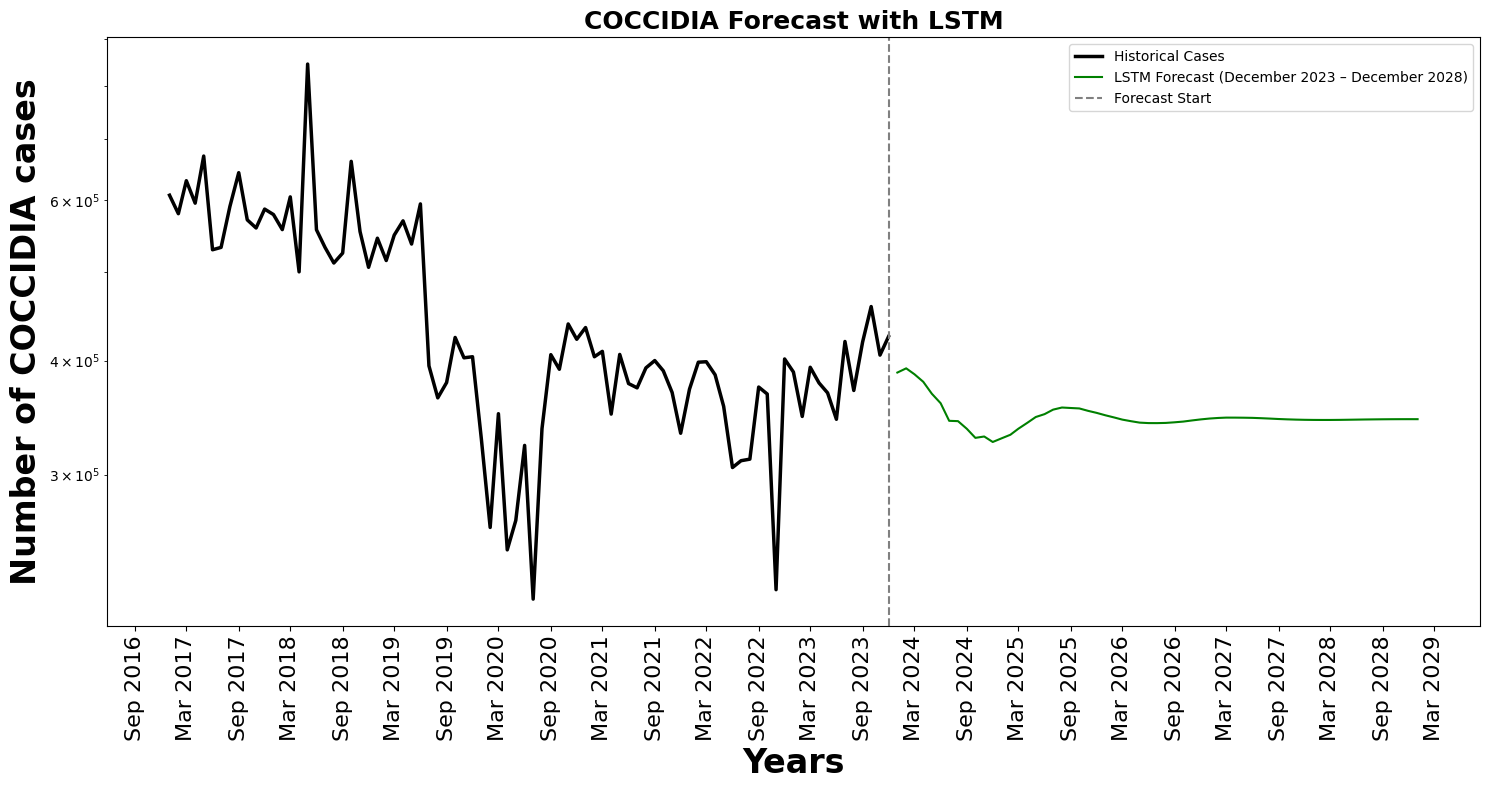

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [19]:
##########LSTM MODEL########

# 📚 Import libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense
from sklearn.preprocessing import MinMaxScaler
import matplotlib.dates as mdates

# 🔄 Read & preprocess
file_name = list(uploaded.keys())[0]
df = pd.read_excel(file_name, sheet_name='Sheet12')
df['Date'] = pd.to_datetime(df['Date'])
df = df.set_index('Date').asfreq('MS')
df = df.sort_index().fillna(method='ffill')

# 🧠 Add 1 and log-transform the cases
df['COCCIDIA_Cases'] = df['COCCIDIA_Cases'] + 1
df['Cases_log'] = np.log(df['COCCIDIA_Cases'])

# 📏 Normalize log data for LSTM
scaler = MinMaxScaler()
scaled_log_cases = scaler.fit_transform(df[['Cases_log']])

# 🧠 Create sequences for LSTM
def create_sequences(data, window_size):
    X, y = [], []
    for i in range(window_size, len(data)):
        X.append(data[i-window_size:i])
        y.append(data[i])
    return np.array(X), np.array(y)

window_size = 12  # 12 months = 1 year
X, y = create_sequences(scaled_log_cases, window_size)

# 🧠 Reshape input to [samples, time steps, features]
X = X.reshape((X.shape[0], X.shape[1], 1))

# 🤖 Define and train LSTM model
model = Sequential([
    LSTM(64, activation='relu', input_shape=(window_size, 1)),
    Dense(1)
])
model.compile(optimizer='adam', loss='mse')
model.fit(X, y, epochs=200, batch_size=8, verbose=1)

# 🔮 Forecasting future values
n_future_months = 61  # From Dec 2023 to Dec 2028
forecast_inputs = scaled_log_cases[-window_size:].reshape(1, window_size, 1)
predictions_scaled = []

for _ in range(n_future_months):
    pred = model.predict(forecast_inputs, verbose=0)  # pred shape: (1,1)
    predictions_scaled.append(pred[0, 0])
    forecast_inputs = np.append(forecast_inputs[:, 1:, :], pred.reshape(1, 1, 1), axis=1)


# 🔄 Inverse transform and back-calculate original values
log_preds = scaler.inverse_transform(np.array(predictions_scaled).reshape(-1, 1)).flatten()
forecast_cases = np.exp(log_preds) - 1  # Undo log and subtract 1

# 📅 Create forecast date range
last_date = df.index[-1]
future_dates = pd.date_range(start=last_date + pd.DateOffset(months=1), periods=n_future_months, freq='MS')
forecast_series = pd.Series(forecast_cases, index=future_dates)

# 📈 Plotting
plt.figure(figsize=(15, 8))
plt.plot(df.index, df['COCCIDIA_Cases'], label='Historical Cases', color='black', linewidth=2.5)
plt.plot(forecast_series.index, forecast_series, label='LSTM Forecast (December 2023 – December 2028)', color='green')
plt.axvline(df.index[-1], color='gray', linestyle='--', label='Forecast Start')
plt.yscale('log')

plt.title('COCCIDIA Forecast with LSTM', fontsize=18, fontweight='bold')
plt.xlabel('Years', fontsize=24, fontweight='bold')
plt.ylabel('Number of COCCIDIA cases', fontsize=24, fontweight='bold')
plt.tick_params(axis='both', labelsize=16)
plt.legend()

plt.gca().xaxis.set_major_locator(mdates.MonthLocator(interval=6))
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
plt.xticks(rotation=90)

plt.tight_layout()
plt.savefig("COCCIDIA_LSTM.tiff", dpi=300, format='tiff')
plt.show()

# ✅ Download the TIFF (Uncomment when running in Colab)
from google.colab import files
files.download("COCCIDIA_LSTM.tiff")


In [20]:
########LSTM RMSE, MAE, R², Accuracy##########
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from math import sqrt
import numpy as np

# 🔮 Predict on training set
y_pred_lstm_scaled = model.predict(X)

# 🔁 Inverse transform from scaled log values
y_pred_lstm_log = scaler.inverse_transform(y_pred_lstm_scaled)
y_true_lstm_log = scaler.inverse_transform(y)

# ⏪ Convert back to original scale
y_pred_lstm = np.exp(y_pred_lstm_log.flatten()) - 1
y_true_lstm = np.exp(y_true_lstm_log.flatten()) - 1

# 📉 RMSE
rmse_lstm = sqrt(mean_squared_error(y_true_lstm, y_pred_lstm))
print(f'LSTM Train RMSE: {rmse_lstm:.2f}')

# 📉 MAE
mae_lstm = mean_absolute_error(y_true_lstm, y_pred_lstm)
print(f'LSTM Train MAE: {mae_lstm:.2f}')

# 📈 R²
r2_lstm = r2_score(y_true_lstm, y_pred_lstm)
print(f'LSTM Train R²: {r2_lstm:.4f}')

# 📊 Accuracy (100 - MAPE)
mape_lstm = np.mean(np.abs((y_true_lstm - y_pred_lstm) / y_true_lstm)) * 100
accuracy_lstm = 100 - mape_lstm
print(f'LSTM Train Accuracy (100 - MAPE): {accuracy_lstm:.2f}%')


3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step 
LSTM Train RMSE: 55497.08
LSTM Train MAE: 39432.92
LSTM Train R²: 0.7209
LSTM Train Accuracy (100 - MAPE): 90.12%


DEBUG:cmdstanpy:input tempfile: /tmp/tmplivfu_nf/fns2jihc.json
DEBUG:cmdstanpy:input tempfile: /tmp/tmplivfu_nf/yn9tmzw2.json
DEBUG:cmdstanpy:idx 0
DEBUG:cmdstanpy:running CmdStan, num_threads: None
DEBUG:cmdstanpy:CmdStan args: ['/usr/local/lib/python3.12/dist-packages/prophet/stan_model/prophet_model.bin', 'random', 'seed=24592', 'data', 'file=/tmp/tmplivfu_nf/fns2jihc.json', 'init=/tmp/tmplivfu_nf/yn9tmzw2.json', 'output', 'file=/tmp/tmplivfu_nf/prophet_model01yf9i_0/prophet_model-20250825190120.csv', 'method=optimize', 'algorithm=newton', 'iter=10000']
19:01:20 - cmdstanpy - INFO - Chain [1] start processing
INFO:cmdstanpy:Chain [1] start processing
19:01:21 - cmdstanpy - INFO - Chain [1] done processing
INFO:cmdstanpy:Chain [1] done processing


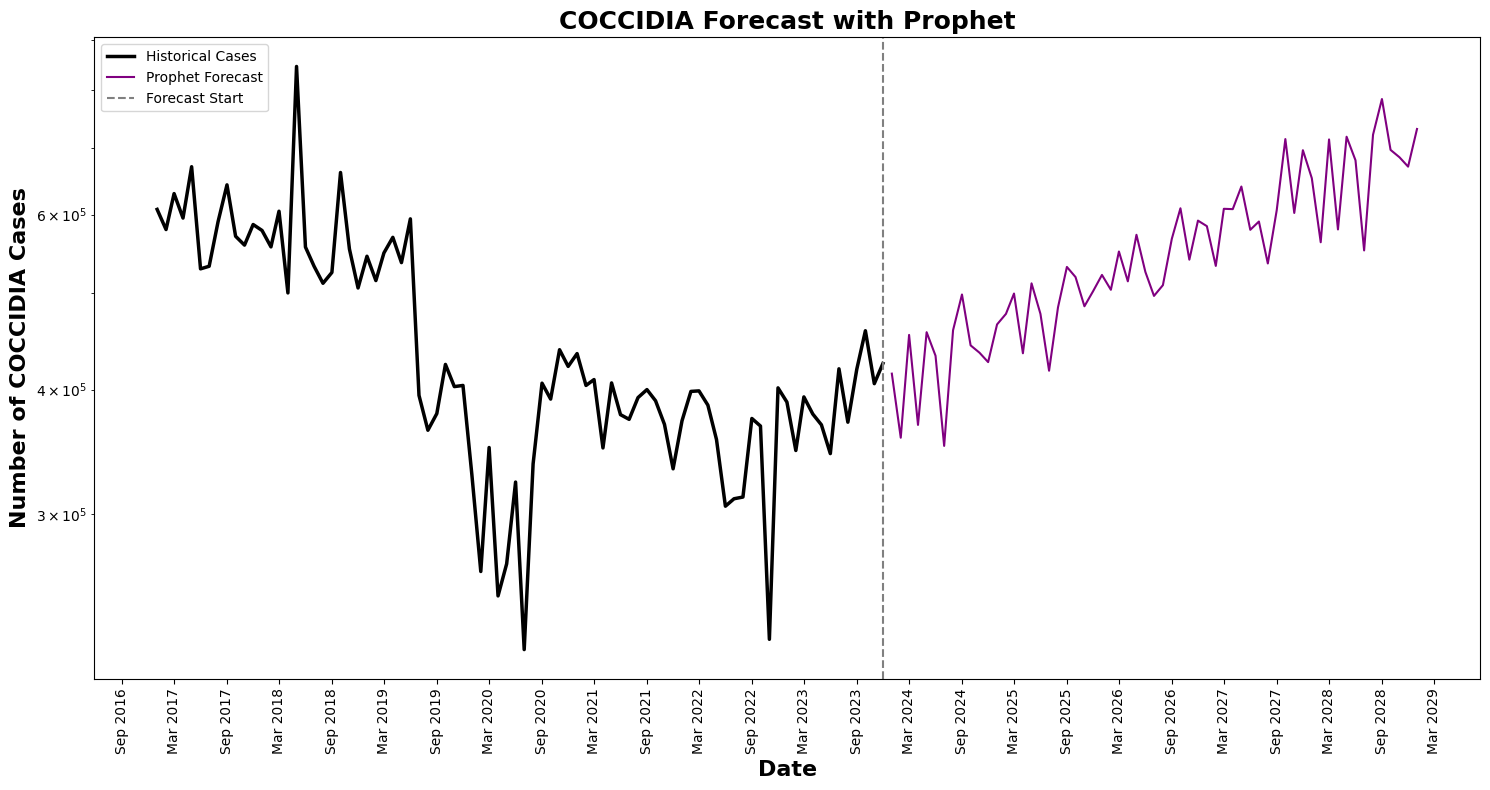

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [21]:
########prophet model######

#!pip install prophet

import pandas as pd

# Reset index and rename columns for Prophet
df_prophet = df.reset_index()[['Date', 'COCCIDIA_Cases']].rename(columns={'Date': 'ds', 'COCCIDIA_Cases': 'y'})

df_prophet['y'] = np.log(df_prophet['y'] + 1)  # Add 1 to avoid log(0)
from prophet import Prophet

model = Prophet(yearly_seasonality=True, weekly_seasonality=False, daily_seasonality=False)
model.fit(df_prophet)

future = model.make_future_dataframe(periods=61, freq='MS')  # 61 months into the future (until Dec 2028)
forecast = model.predict(future)

# Last date of observed data
forecast_start_date = df_prophet['ds'].max()

# Full forecast (historical + future)
forecast = model.predict(future)

# Calculate original scale if you use log transform
forecast['yhat_orig'] = np.exp(forecast['yhat']) - 1

# Filter forecast to keep only future dates after last historical date
future_forecast = forecast[forecast['ds'] > forecast_start_date]

# Plot historical and forecast separately
plt.figure(figsize=(15, 8))
plt.plot(df_prophet['ds'], np.exp(df_prophet['y']) - 1, label='Historical Cases', color='black', linewidth=2.5)
plt.plot(future_forecast['ds'], future_forecast['yhat_orig'], label='Prophet Forecast', color='purple')
plt.axvline(forecast_start_date, color='gray', linestyle='--', label='Forecast Start')

plt.yscale('log')
plt.title('COCCIDIA Forecast with Prophet', fontsize=18, fontweight='bold')
plt.xlabel('Date', fontsize=16, fontweight='bold')
plt.ylabel('Number of COCCIDIA Cases', fontsize=16, fontweight='bold')
plt.legend()

import matplotlib.dates as mdates
ax = plt.gca()
ax.xaxis.set_major_locator(mdates.MonthLocator(interval=6))  # 6-month breaks
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
plt.xticks(rotation=90)

plt.tight_layout()
plt.savefig("COCCIDIA_prophet.tiff", dpi=300, format='tiff')
plt.show()

# ✅ Download the TIFF (Uncomment when running in Colab)
from google.colab import files
files.download("COCCIDIA_prophet.tiff")


In [22]:
############ RMSE, MAE, R², Accuracy of Prophet #########
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from math import sqrt
import numpy as np

# ✅ Align predictions with the training data
df_train_forecast = forecast[forecast['ds'] <= df_prophet['ds'].max()]

# ✅ Back-transform from log scale
y_true = np.exp(df_prophet['y']) - 1
y_pred = np.exp(df_train_forecast['yhat']) - 1

# 📉 RMSE
rmse = sqrt(mean_squared_error(y_true, y_pred))
print(f'Prophet Train RMSE: {rmse:.2f}')

# 📉 MAE
mae = mean_absolute_error(y_true, y_pred)
print(f'Prophet Train MAE: {mae:.2f}')

# 📈 R²
r2 = r2_score(y_true, y_pred)
print(f'Prophet Train R²: {r2:.4f}')

# 📊 Accuracy (100 - MAPE)
mape = np.mean(np.abs((y_true - y_pred) / y_true)) * 100
accuracy = 100 - mape
print(f'Prophet Train Accuracy (100 - MAPE): {accuracy:.2f}%')



Prophet Train RMSE: 43118.56
Prophet Train MAE: 28811.07
Prophet Train R²: 0.8604
Prophet Train Accuracy (100 - MAPE): 93.18%


Epoch 1/200


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


9/9 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - loss: 213.0413
Epoch 2/200
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 22.0845 
Epoch 3/200
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 1.4998 
Epoch 4/200
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 2.6948 
Epoch 5/200
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.1297 
Epoch 6/200
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.4563 
Epoch 7/200
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.0777
Epoch 8/200
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.1066 
Epoch 9/200
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.0517 
Epoch 10/200
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.0477
Epoch 11/200
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.0484 
Epoch 12/200
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.0418
Epoch 13/200
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.0437
Epoch 14/200
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.0350 
Epoch 15/200
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.0575 
Epoch 16/200
9/9 ━━━━━━━━━━━━

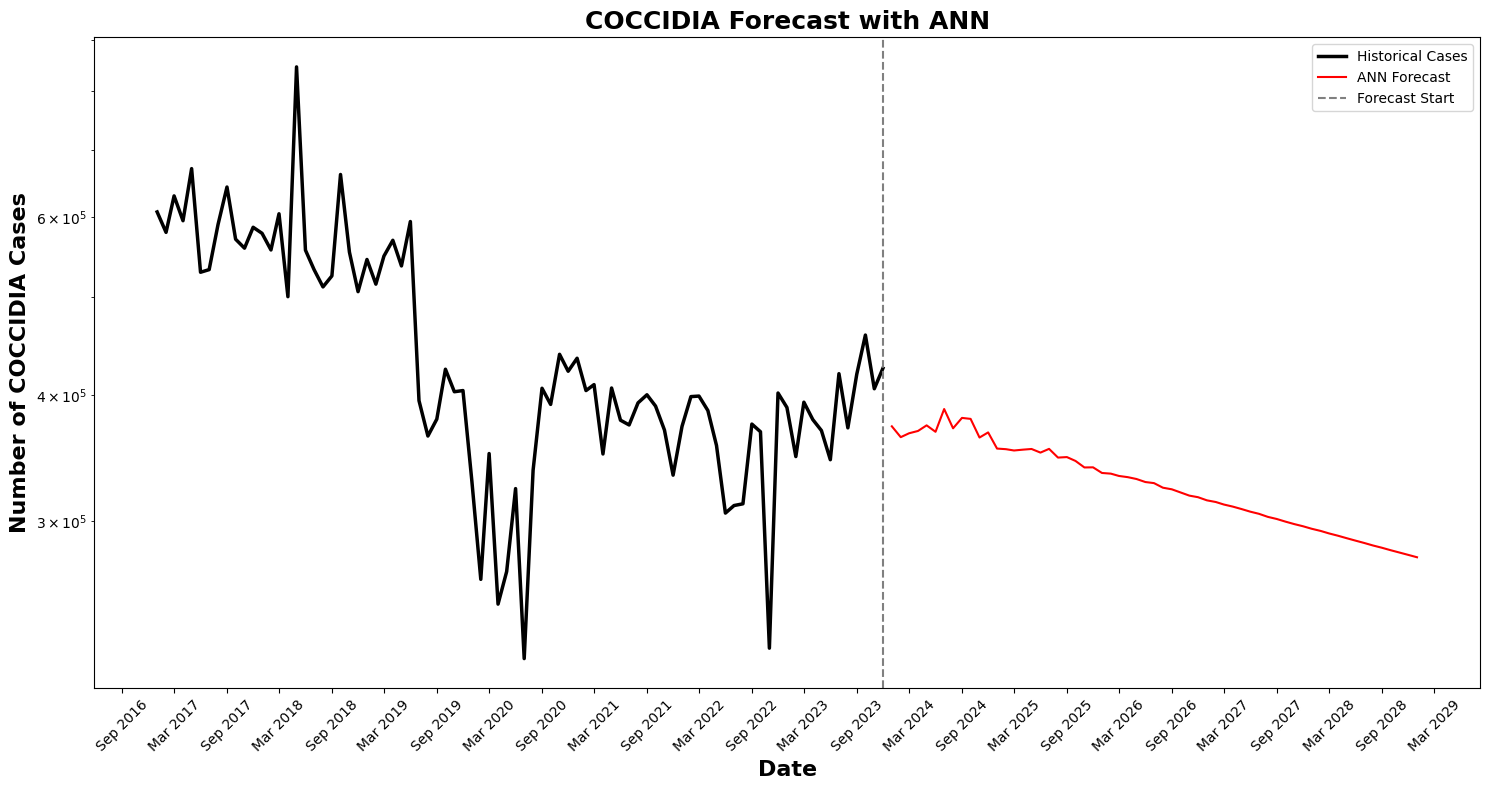

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [23]:
############# ANNN ############

import numpy as np
import pandas as pd

# Assuming df['Cases_log'] is your log-transformed target (like in your code)
series = df['Cases_log'].values

window_size = 12  # Use last 12 months as features
X, y = [], []
for i in range(window_size, len(series)):
    X.append(series[i-window_size:i])
    y.append(series[i])

X = np.array(X)
y = np.array(y)
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.optimizers import Adam

model = Sequential()
model.add(Dense(64, activation='relu', input_shape=(window_size,)))
model.add(Dense(32, activation='relu'))
model.add(Dense(1))  # Regression output

model.compile(optimizer=Adam(learning_rate=0.001), loss='mse')

model.fit(X, y, epochs=200, batch_size=8, verbose=1)
n_future = 61  # months to forecast
input_seq = series[-window_size:].tolist()
predictions = []

for _ in range(n_future):
    x_input = np.array(input_seq[-window_size:]).reshape(1, window_size)
    y_pred = model.predict(x_input, verbose=0)[0, 0]
    predictions.append(y_pred)
    input_seq.append(y_pred)

# Back-transform from log-scale
predicted_cases = np.exp(np.array(predictions)) - 1
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

last_date = df.index[-1]
future_dates = pd.date_range(start=last_date + pd.DateOffset(months=1), periods=n_future, freq='MS')

plt.figure(figsize=(15, 8))
plt.plot(df.index, df['COCCIDIA_Cases'], label='Historical Cases', color='black', linewidth=2.5)
plt.plot(future_dates, predicted_cases, label='ANN Forecast', color='red')
plt.axvline(last_date, color='gray', linestyle='--', label='Forecast Start')

plt.yscale('log')
plt.title('COCCIDIA Forecast with ANN', fontsize=18, fontweight='bold')
plt.xlabel('Date', fontsize=16, fontweight='bold')
plt.ylabel('Number of COCCIDIA Cases', fontsize=16, fontweight='bold')
plt.legend()

ax = plt.gca()
ax.xaxis.set_major_locator(mdates.MonthLocator(interval=6))
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
plt.xticks(rotation=45)

plt.tight_layout()
plt.savefig("COCCIDIA_ANN.tiff", dpi=300, format='tiff')
plt.show()

# ✅ Download the TIFF (Uncomment when running in Colab)
from google.colab import files
files.download("COCCIDIA_ANN.tiff")

In [24]:
### ANN RMSE, MAE, R², and Accuracy ###

from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from math import sqrt
import numpy as np

# 🔮 Predict on training data
y_pred_train = model.predict(X).flatten()

# 🔁 Back-transform from log scale
y_pred_train_cases = np.exp(y_pred_train) - 1
y_true_train_cases = np.exp(y) - 1

# 📉 RMSE
rmse_ann = sqrt(mean_squared_error(y_true_train_cases, y_pred_train_cases))
print(f'ANN Train RMSE: {rmse_ann:.2f}')

# 📉 MAE
mae_ann = mean_absolute_error(y_true_train_cases, y_pred_train_cases)
print(f'ANN Train MAE: {mae_ann:.2f}')

# 📈 R²
r2_ann = r2_score(y_true_train_cases, y_pred_train_cases)
print(f'ANN Train R²: {r2_ann:.4f}')

# 📊 Accuracy (100 - MAPE)
mape_ann = np.mean(np.abs((y_true_train_cases - y_pred_train_cases) / y_true_train_cases)) * 100
accuracy_ann = 100 - mape_ann
print(f'ANN Train Accuracy (100 - MAPE): {accuracy_ann:.2f}%')


3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step
ANN Train RMSE: 77956.13
ANN Train MAE: 60557.02
ANN Train R²: 0.4492
ANN Train Accuracy (100 - MAPE): 84.15%
